# 02 — Preprocesamiento: Resize, Split y Estadísticas de Normalización

**Entregable 2 – Deep Learning**  
Estado del Arte, EDA Mejorado e Implementación de Modelos Benchmark

---

> **Objetivo de este notebook**  
> Transformar el subset MSL del dataset AI4MARS en los artefactos listos para entrenamiento:
> 1. Seleccionar un **subconjunto estratificado de 6.000 imágenes MSL** del pool de entrenamiento.
> 2. Generar el **split train/val (70/30)** y persistirlo en disco.
> 3. Hacer **resize a 256×256** de imágenes (BILINEAR) y máscaras (NEAREST).
> 4. Calcular **estadísticas de normalización** exclusivamente sobre el train set.
> 5. Calcular **pesos de clase** exclusivamente sobre el train set.
>
> **Prerrequisito**: `01_eda_exploratorio.ipynb` debe haberse ejecutado completamente.  
> Los archivos `processed/manifest_msl_train.csv` y `processed/manifest_msl_gold_test.csv` deben existir.

---

**Índice**
1. Configuración e importaciones
2. Carga del manifest MSL
3. Selección estratificada de 6.000 imágenes
4. Generación y persistencia del split train/val
5. Resize y guardado de imágenes y máscaras
6. Verificación de integridad del resize
7. Estadísticas de normalización (solo train)
8. Pesos de clase (solo train)
9. Verificación final: no data leakage
10. Resumen de artefactos generados

## 1. Configuración e importaciones <a id="setup"></a>

In [ ]:
import os
import json
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# ── Raíz del proyecto: un nivel arriba de notebooks/ ────────────────────────
NOTEBOOK_DIR = Path().resolve()
ROOT         = NOTEBOOK_DIR.parent

# ── Directorios de entrada (generados por notebook 01) ───────────────────────
PROCESSED_DIR = ROOT / "processed"

# ── Directorios de salida (imágenes resizadas) ───────────────────────────────
DATA_DIR      = ROOT / "data"
IMAGES_256    = DATA_DIR / "images_256"
MASKS_256     = DATA_DIR / "masks_256"

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_256.mkdir(parents=True, exist_ok=True)
MASKS_256.mkdir(parents=True, exist_ok=True)

# ── Constantes del proyecto ──────────────────────────────────────────────────
NUM_CLASSES  = 4
IGNORE_INDEX = 255
IMG_SIZE     = 256
N_SUBSET     = 6000   # imágenes MSL en el pool train+val
VAL_RATIO    = 0.30   # 70% train / 30% val
SEED         = 42

CLASS_NAMES = {0: "soil", 1: "bedrock", 2: "sand", 3: "big_rock"}
CLASS_COLORS = {
    0: "#E69F00",
    1: "#56B4E9",
    2: "#009E73",
    3: "#D55E00",
}

print(f"Raíz del proyecto : {ROOT}")
print(f"Processed dir     : {PROCESSED_DIR}")
print(f"Images 256 dir    : {IMAGES_256}")
print(f"Masks  256 dir    : {MASKS_256}")
print(f"\nParámetros:")
print(f"  N_SUBSET  = {N_SUBSET:,}")
print(f"  IMG_SIZE  = {IMG_SIZE}×{IMG_SIZE}")
print(f"  VAL_RATIO = {VAL_RATIO} (train={1-VAL_RATIO:.0%} / val={VAL_RATIO:.0%})")
print(f"  SEED      = {SEED}")

# ── Verificar prerrequisitos ──────────────────────────────────────────────────
MANIFEST_TRAIN = PROCESSED_DIR / "manifest_msl_train.csv"
MANIFEST_GOLD  = PROCESSED_DIR / "manifest_msl_gold_test.csv"

print("\nVerificando prerrequisitos:")
for name, path in [("manifest_msl_train.csv", MANIFEST_TRAIN),
                   ("manifest_msl_gold_test.csv", MANIFEST_GOLD)]:
    status = "✓" if path.exists() else "✗ NO ENCONTRADO — ejecutar 01_eda_exploratorio.ipynb"
    print(f"  [{status}] {name}")

assert MANIFEST_TRAIN.exists(), "Falta manifest_msl_train.csv — ejecutar 01_eda_exploratorio.ipynb primero."
assert MANIFEST_GOLD.exists(),  "Falta manifest_msl_gold_test.csv — ejecutar 01_eda_exploratorio.ipynb primero."

Raíz del proyecto : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3
Processed dir     : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\notebooks\processed
Images 256 dir    : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\data\images_256
Masks  256 dir    : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\data\masks_256

Parámetros:
  N_SUBSET  = 6,000
  IMG_SIZE  = 256×256
  VAL_RATIO = 0.3 (train=70% / val=30%)
  SEED      = 42

Verificando prerrequisitos:
  [✓] manifest_msl_train.csv
  [✓] manifest_msl_gold_test.csv


## 2. Carga del manifest MSL <a id="manifest"></a>

In [2]:
df_msl_train = pd.read_csv(MANIFEST_TRAIN)
df_gold      = pd.read_csv(MANIFEST_GOLD)

print(f"Pool MSL train : {len(df_msl_train):,} imágenes")
print(f"Gold set MSL   : {len(df_gold):,} imágenes")
print(f"\nColumnas: {list(df_msl_train.columns)}")
print(f"\nPrimeras filas del manifest:")
df_msl_train.head(3)

Pool MSL train : 15,901 imágenes
Gold set MSL   : 322 imágenes

Columnas: ['mission', 'camera', 'id', 'image_path', 'mask_path', 'split']

Primeras filas del manifest:


,mission,camera,id,image_path,mask_path,split
0,MSL,ncam,NLA_397681339EDR_F0020000AUT_04096M1,msl\ncam\images\edr\NLA_397681339EDR_F0020000A...,msl\ncam\labels\train\NLA_397681339EDR_F002000...,train
1,MSL,ncam,NLA_397681372EDR_F0020000AUT_04096M1,msl\ncam\images\edr\NLA_397681372EDR_F0020000A...,msl\ncam\labels\train\NLA_397681372EDR_F002000...,train
2,MSL,ncam,NLA_397681398EDR_F0020000AUT_04096M1,msl\ncam\images\edr\NLA_397681398EDR_F0020000A...,msl\ncam\labels\train\NLA_397681398EDR_F002000...,train


## 3. Selección estratificada de 6.000 imágenes <a id="subset"></a>

Para que el subset sea representativo del dataset completo MSL,
la selección se hace **estratificada por clase dominante** de la máscara.
Esto garantiza que ninguna clase quede sub-representada en el pool de 6.000.

La clase dominante de cada imagen se define como la clase válida (0–3)
con más píxeles en la máscara (excluyendo `ignore=255`).

In [3]:
def get_dominant_class(mask_rel_path: str, root: Path) -> int:
    """
    Devuelve la clase válida (0-3) con más píxeles en la máscara.
    Si la máscara no tiene clases válidas, retorna -1.
    """
    mask = np.array(Image.open(root / mask_rel_path))
    counts = {}
    for c in range(4):
        counts[c] = int(np.sum(mask == c))
    valid = {c: v for c, v in counts.items() if v > 0}
    if not valid:
        return -1
    return max(valid, key=valid.get)


# Verificar si ya existe el CSV con clases dominantes para no recomputar
dominant_cache = PROCESSED_DIR / "manifest_msl_dominant.csv"

if dominant_cache.exists():
    print("Cargando clases dominantes desde caché...")
    df_msl_train = pd.read_csv(dominant_cache)
else:
    print(f"Calculando clase dominante para {len(df_msl_train):,} imágenes...")
    dominant = []
    for _, row in tqdm(df_msl_train.iterrows(), total=len(df_msl_train),
                       desc="Clase dominante"):
        dominant.append(get_dominant_class(row["mask_path"], ROOT))
    df_msl_train["dominant_class"] = dominant
    df_msl_train = df_msl_train[df_msl_train["dominant_class"] >= 0].reset_index(drop=True)
    df_msl_train.to_csv(dominant_cache, index=False)
    print(f"Caché guardado en {dominant_cache.name}")

print(f"\nDistribución de clase dominante en el pool MSL completo:")
dom_counts = df_msl_train["dominant_class"].value_counts().sort_index()
for cls_id, count in dom_counts.items():
    pct = count / len(df_msl_train) * 100
    print(f"  {CLASS_NAMES[cls_id]:10s} (clase {cls_id}): {count:>5,} imágenes ({pct:.1f}%)")

Calculando clase dominante para 15,901 imágenes...


Clase dominante: 100%|██████████| 15901/15901 [01:31<00:00, 174.54it/s]


Caché guardado en manifest_msl_dominant.csv

Distribución de clase dominante en el pool MSL completo:
  soil       (clase 0): 5,767 imágenes (36.3%)
  bedrock    (clase 1): 8,234 imágenes (51.8%)
  sand       (clase 2): 1,792 imágenes (11.3%)
  big_rock   (clase 3):   108 imágenes (0.7%)



Subset seleccionado: 6,000 imágenes

Distribución de clase dominante en el subset (debe ser ~proporcional al pool):
  soil      : 2,176 (36.3%)  |  pool: 36.3%)
  bedrock   : 3,107 (51.8%)  |  pool: 51.8%)
  sand      :   676 (11.3%)  |  pool: 11.3%)
  big_rock  :    41 (0.7%)  |  pool: 0.7%)


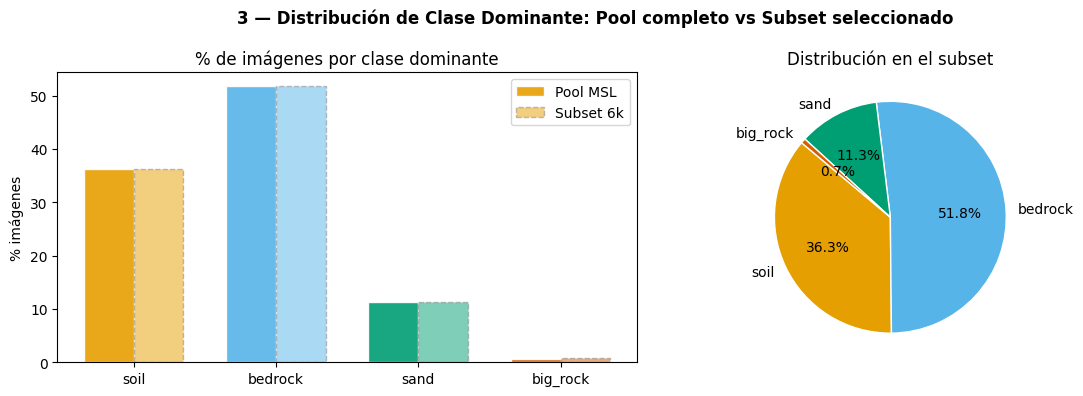

In [4]:
# ── Selección estratificada ──────────────────────────────────────────────────
n_to_select = min(N_SUBSET, len(df_msl_train))

if n_to_select < len(df_msl_train):
    # Selección estratificada por clase dominante
    df_subset, _ = train_test_split(
        df_msl_train,
        train_size=n_to_select,
        stratify=df_msl_train["dominant_class"],
        random_state=SEED
    )
    df_subset = df_subset.reset_index(drop=True)
else:
    df_subset = df_msl_train.copy()
    print(f"El pool MSL tiene {len(df_msl_train):,} imágenes — se usan todas.")

print(f"\nSubset seleccionado: {len(df_subset):,} imágenes")
print(f"\nDistribución de clase dominante en el subset (debe ser ~proporcional al pool):")
sub_counts = df_subset["dominant_class"].value_counts().sort_index()
for cls_id, count in sub_counts.items():
    pct_sub  = count / len(df_subset) * 100
    pct_pool = dom_counts.get(cls_id, 0) / len(df_msl_train) * 100
    print(f"  {CLASS_NAMES[cls_id]:10s}: {count:>5,} ({pct_sub:.1f}%)  |  pool: {pct_pool:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("3 — Distribución de Clase Dominante: Pool completo vs Subset seleccionado",
             fontsize=12, fontweight="bold")

cls_labels = [CLASS_NAMES[c] for c in range(4)]
colors_cls = [CLASS_COLORS[c] for c in range(4)]
x = np.arange(4)
w = 0.35

pool_vals   = [dom_counts.get(c, 0) / len(df_msl_train) * 100 for c in range(4)]
subset_vals = [sub_counts.get(c, 0) / len(df_subset) * 100 for c in range(4)]

axes[0].bar(x - w/2, pool_vals,   w, label="Pool MSL",   color=colors_cls, alpha=0.9, edgecolor="white")
axes[0].bar(x + w/2, subset_vals, w, label="Subset 6k", color=colors_cls, alpha=0.5, edgecolor="gray", linestyle="--")
axes[0].set_xticks(x); axes[0].set_xticklabels(cls_labels)
axes[0].set_ylabel("% imágenes")
axes[0].set_title("% de imágenes por clase dominante")
axes[0].legend(["Pool MSL", "Subset 6k"])

axes[1].pie(sub_counts.values, labels=[CLASS_NAMES[c] for c in sub_counts.index],
            colors=[CLASS_COLORS[c] for c in sub_counts.index],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Distribución en el subset")

plt.tight_layout()
plt.show()

## 4. Generación y persistencia del split train/val <a id="split"></a>

> ⚠️ **CRÍTICO**: Este split se genera **una sola vez** y se guarda en `split_indices_msl6k.pkl`.
> Todos los modelos deben usar exactamente el mismo split.
> **No regenerar con otra semilla.**
>
> El archivo `split_indices_msl6k.pkl` debe subirse al repositorio.

In [5]:
SPLIT_FILE = PROCESSED_DIR / "split_indices_msl6k.pkl"

if SPLIT_FILE.exists():
    print("⚠️  split_indices_msl6k.pkl ya existe — cargando split existente.")
    print("   NO se regenera para garantizar reproducibilidad entre compañeros.")
    with open(SPLIT_FILE, "rb") as f:
        split_data = pickle.load(f)
    train_ids = split_data["train_ids"]
    val_ids   = split_data["val_ids"]
    print(f"   Train: {len(train_ids):,} | Val: {len(val_ids):,}")
else:
    print("Generando split train/val estratificado...")
    train_df, val_df = train_test_split(
        df_subset,
        test_size=VAL_RATIO,
        stratify=df_subset["dominant_class"],
        random_state=SEED
    )
    train_ids = train_df["id"].tolist()
    val_ids   = val_df["id"].tolist()

    split_data = {
        "train_ids":    train_ids,
        "val_ids":      val_ids,
        "seed":         SEED,
        "n_subset":     N_SUBSET,
        "val_ratio":    VAL_RATIO,
        "stratify_col": "dominant_class",
    }
    with open(SPLIT_FILE, "wb") as f:
        pickle.dump(split_data, f)
    print(f"✓ split_indices_msl6k.pkl guardado")
    print(f"  Train: {len(train_ids):,} imágenes | Val: {len(val_ids):,} imágenes")

# Reconstruir dataframes de train y val a partir de los IDs
train_df = df_subset[df_subset["id"].isin(train_ids)].reset_index(drop=True)
val_df   = df_subset[df_subset["id"].isin(val_ids)].reset_index(drop=True)

print(f"\nSplit final:")
print(f"  Train : {len(train_df):>5,} imágenes  ({len(train_df)/len(df_subset):.1%})")
print(f"  Val   : {len(val_df):>5,} imágenes  ({len(val_df)/len(df_subset):.1%})")
print(f"  Test  :   322 imágenes  (gold set fijo — no toca este notebook)")

# Verificar que no hay overlap entre train y val
overlap = set(train_ids) & set(val_ids)
assert len(overlap) == 0, f"Overlap entre train y val: {len(overlap)} IDs"
print(f"\n✓ Sin overlap entre train y val")

Generando split train/val estratificado...
✓ split_indices_msl6k.pkl guardado
  Train: 4,200 imágenes | Val: 1,800 imágenes

Split final:
  Train : 4,200 imágenes  (70.0%)
  Val   : 1,800 imágenes  (30.0%)
  Test  :   322 imágenes  (gold set fijo — no toca este notebook)

✓ Sin overlap entre train y val


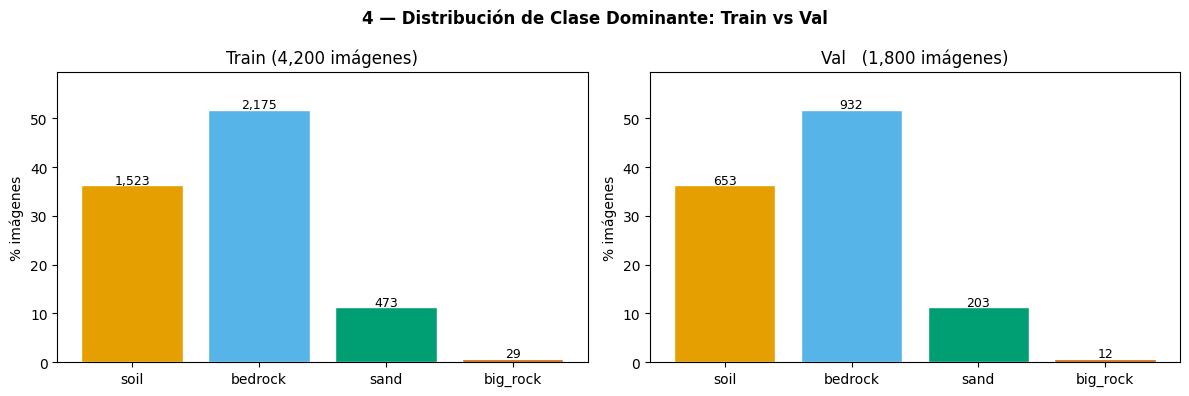

Proporciones por clase (train vs val — deben ser similares):
Clase           Train %      Val %
soil              36.26%      36.28%
bedrock           51.79%      51.78%
sand              11.26%      11.28%
big_rock           0.69%       0.67%


In [6]:
# Verificar estratificación del split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("4 — Distribución de Clase Dominante: Train vs Val",
             fontsize=12, fontweight="bold")

for ax, df_split, title in [
    (axes[0], train_df, f"Train ({len(train_df):,} imágenes)"),
    (axes[1], val_df,   f"Val   ({len(val_df):,} imágenes)"),
]:
    counts = df_split["dominant_class"].value_counts().sort_index()
    bars = ax.bar(
        [CLASS_NAMES[c] for c in counts.index],
        [v / len(df_split) * 100 for v in counts.values],
        color=[CLASS_COLORS[c] for c in counts.index],
        edgecolor="white"
    )
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f"{val:,}", ha="center", fontsize=9)
    ax.set_ylabel("% imágenes")
    ax.set_title(title)
    ax.set_ylim(0, max([v / len(df_split) * 100 for v in counts.values]) * 1.15)

plt.tight_layout()
plt.show()

print("Proporciones por clase (train vs val — deben ser similares):")
print(f"{'Clase':12s} {'Train %':>10s} {'Val %':>10s}")
for c in range(4):
    t_pct = (train_df["dominant_class"] == c).sum() / len(train_df) * 100
    v_pct = (val_df["dominant_class"] == c).sum()   / len(val_df)   * 100
    print(f"{CLASS_NAMES[c]:12s} {t_pct:>10.2f}% {v_pct:>10.2f}%")

## 5. Resize y guardado de imágenes y máscaras <a id="resize"></a>

- **Imágenes**: resize a 256×256 con `BILINEAR`, guardadas como **JPEG quality=95**.
- **Máscaras**: resize a 256×256 con `NEAREST` (preserva valores exactos de clase), guardadas como **PNG**.
- Si el archivo de salida ya existe, se salta (permite resumir en caso de interrupción).

In [7]:
def resize_and_save_image(src_path: Path, dst_path: Path, size: int) -> None:
    """Abre imagen, convierte a RGB (replicando gris si es necesario), resize BILINEAR, guarda JPEG."""
    img = Image.open(src_path).convert("RGB")
    img = img.resize((size, size), Image.BILINEAR)
    img.save(dst_path, format="JPEG", quality=95)


def resize_and_save_mask(src_path: Path, dst_path: Path, size: int) -> None:
    """Abre máscara, resize NEAREST (preserva valores exactos), guarda PNG."""
    mask = Image.open(src_path)
    mask = mask.resize((size, size), Image.NEAREST)
    mask.save(dst_path, format="PNG")


def process_dataframe(
    df: pd.DataFrame,
    root: Path,
    images_out: Path,
    masks_out:  Path,
    size: int,
    desc: str = "Procesando"
) -> tuple[int, int]:
    """
    Itera sobre el dataframe y hace resize + guardado de imagen y máscara.
    Retorna (n_procesados, n_saltados).
    """
    n_proc, n_skip = 0, 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        stem = Path(row["image_path"]).stem

        img_dst  = images_out / f"{stem}.jpg"
        mask_dst = masks_out  / f"{stem}.png"

        img_exists  = img_dst.exists()
        mask_exists = mask_dst.exists()

        if not img_exists:
            resize_and_save_image(root / row["image_path"], img_dst, size)
        if not mask_exists:
            resize_and_save_mask(root / row["mask_path"], mask_dst, size)

        if img_exists and mask_exists:
            n_skip += 1
        else:
            n_proc += 1

    return n_proc, n_skip


# Todas las imágenes que necesitamos: subset (train+val) + gold set
df_all_to_resize = pd.concat([df_subset, df_gold], ignore_index=True).drop_duplicates(subset="id")
print(f"Total de imágenes a procesar: {len(df_all_to_resize):,}")
print(f"  Subset (train+val): {len(df_subset):,}")
print(f"  Gold set (test)   : {len(df_gold):,}")
print(f"\nOutput: {IMAGES_256}")
print(f"        {MASKS_256}")

Total de imágenes a procesar: 6,322
  Subset (train+val): 6,000
  Gold set (test)   : 322

Output: C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\data\images_256
        C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\data\masks_256


In [8]:
print("Iniciando resize...")
print("(Si se interrumpe, re-ejecutar esta celda — los archivos ya guardados se saltarán)\n")

n_proc, n_skip = process_dataframe(
    df_all_to_resize,
    root       = ROOT,
    images_out = IMAGES_256,
    masks_out  = MASKS_256,
    size       = IMG_SIZE,
    desc       = "Resize 256×256",
)

total_expected = len(df_all_to_resize)
n_imgs_disk    = len(list(IMAGES_256.glob("*.jpg")))
n_masks_disk   = len(list(MASKS_256.glob("*.png")))

print(f"\nResumen de resize:")
print(f"  Imágenes procesadas : {n_proc + n_skip:,}")
print(f"    Nuevas            : {n_proc:,}")
print(f"    Saltadas (ya existían): {n_skip:,}")
print(f"\n  Archivos en disco:")
print(f"    images_256/: {n_imgs_disk:,} archivos .jpg")
print(f"    masks_256/ : {n_masks_disk:,} archivos .png")

Iniciando resize...
(Si se interrumpe, re-ejecutar esta celda — los archivos ya guardados se saltarán)



Resize 256×256: 100%|██████████| 6322/6322 [01:26<00:00, 73.31it/s]


Resumen de resize:
  Imágenes procesadas : 6,322
    Nuevas            : 6,322
    Saltadas (ya existían): 0

  Archivos en disco:
    images_256/: 6,322 archivos .jpg
    masks_256/ : 6,322 archivos .png


## 6. Verificación de integridad del resize <a id="verificacion"></a>

Se verifica que:
1. El tamaño de las imágenes y máscaras resizadas es exactamente 256×256.
2. Los valores de las máscaras se preservaron correctamente (no se introdujeron clases inexistentes).
3. Las imágenes se muestran visualmente correctas.

In [9]:
print("Verificando integridad del resize (muestra aleatoria de 50 pares)...")

rng = np.random.default_rng(SEED)
sample_ids = rng.choice(len(df_subset), size=50, replace=False)
sample_df  = df_subset.iloc[sample_ids]

errors = []
for _, row in tqdm(sample_df.iterrows(), total=50, desc="Verificando"):
    stem     = Path(row["image_path"]).stem
    img_path  = IMAGES_256 / f"{stem}.jpg"
    mask_path = MASKS_256  / f"{stem}.png"

    if not img_path.exists():
        errors.append(f"Imagen no encontrada: {stem}.jpg")
        continue
    if not mask_path.exists():
        errors.append(f"Máscara no encontrada: {stem}.png")
        continue

    img  = Image.open(img_path)
    mask = np.array(Image.open(mask_path))

    if img.size != (IMG_SIZE, IMG_SIZE):
        errors.append(f"{stem}: imagen tamaño incorrecto {img.size}")
    if mask.shape != (IMG_SIZE, IMG_SIZE):
        errors.append(f"{stem}: máscara forma incorrecta {mask.shape}")

    invalid_values = set(np.unique(mask).tolist()) - {0, 1, 2, 3, 255}
    if invalid_values:
        errors.append(f"{stem}: valores inválidos en máscara {invalid_values}")

if errors:
    print(f"\n⚠️ {len(errors)} errores encontrados:")
    for e in errors[:10]:
        print(f"  {e}")
else:
    print(f"\n✓ Todas las verificaciones pasaron: imágenes {IMG_SIZE}×{IMG_SIZE}, máscaras con valores válidos")

Verificando integridad del resize (muestra aleatoria de 50 pares)...


Verificando: 100%|██████████| 50/50 [00:00<00:00, 1137.22it/s]


✓ Todas las verificaciones pasaron: imágenes 256×256, máscaras con valores válidos


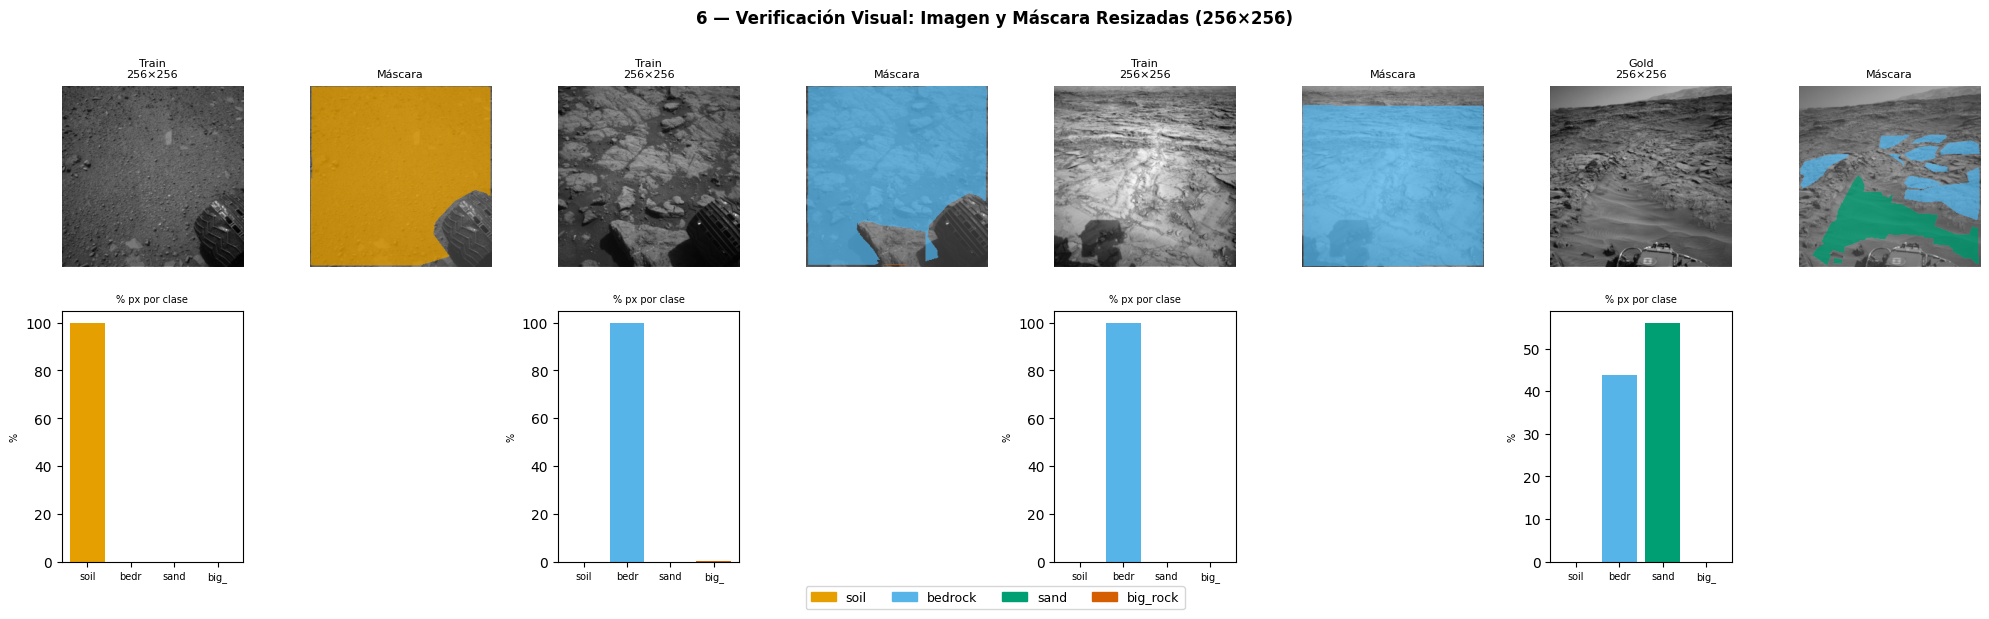

In [10]:
# Inspección visual: 3 pares aleatorios del train y 1 del gold set
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("6 — Verificación Visual: Imagen y Máscara Resizadas (256×256)",
             fontsize=12, fontweight="bold")

samples_train = train_df.sample(3, random_state=SEED)
samples_gold  = df_gold.sample(1,  random_state=SEED)
samples_show  = pd.concat([samples_train, samples_gold], ignore_index=True)
labels_show   = ["Train"] * 3 + ["Gold"]

for col_idx, (_, row) in enumerate(samples_show.iterrows()):
    stem     = Path(row["image_path"]).stem
    img_path  = IMAGES_256 / f"{stem}.jpg"
    mask_path = MASKS_256  / f"{stem}.png"

    img  = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path))

    # Imagen
    axes[0][col_idx * 2].imshow(img, cmap="gray")
    split_label = labels_show[col_idx]
    axes[0][col_idx * 2].set_title(f"{split_label}\n{img.shape[0]}×{img.shape[1]}",
                                    fontsize=8)
    axes[0][col_idx * 2].axis("off")

    # Overlay de máscara
    overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
    for cls_id, hex_color in CLASS_COLORS.items():
        rgb = tuple(int(hex_color[i:i+2], 16) for i in (1, 3, 5))
        overlay[mask == cls_id] = [*rgb, 200]
    overlay[mask == 255] = [150, 150, 150, 80]

    axes[0][col_idx * 2 + 1].imshow(img, cmap="gray")
    axes[0][col_idx * 2 + 1].imshow(overlay)
    axes[0][col_idx * 2 + 1].set_title("Máscara", fontsize=8)
    axes[0][col_idx * 2 + 1].axis("off")

    # Histograma de clases en la máscara
    cls_counts = [(mask == c).sum() for c in range(4)]
    total_valid = sum(cls_counts)
    if total_valid > 0:
        axes[1][col_idx * 2].bar(
            range(4),
            [c / total_valid * 100 for c in cls_counts],
            color=[CLASS_COLORS[c] for c in range(4)]
        )
        axes[1][col_idx * 2].set_xticks(range(4))
        axes[1][col_idx * 2].set_xticklabels(
            [CLASS_NAMES[c][:4] for c in range(4)], fontsize=7
        )
        axes[1][col_idx * 2].set_ylabel("%", fontsize=7)
        axes[1][col_idx * 2].set_title("% px por clase", fontsize=7)
    axes[1][col_idx * 2 + 1].axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in range(4)]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()

## 7. Estadísticas de normalización (solo train) <a id="normalizacion"></a>

> ⚠️ **CRÍTICO — anti data leakage**: Las estadísticas de normalización se calculan
> **exclusivamente sobre el train set**. Aplicarlas a val y test está permitido
> (es el procedimiento estándar), pero calcularlas sobre val/test constituiría data leakage.
>
> Las imágenes se convierten a RGB (3 canales) para compatibilidad con encoders
> preentrenados en ImageNet.

In [11]:
NORM_STATS_FILE = PROCESSED_DIR / "normalization_stats.json"

if NORM_STATS_FILE.exists():
    print("Cargando estadísticas de normalización desde caché...")
    with open(NORM_STATS_FILE) as f:
        norm_stats = json.load(f)
    print(f"  mean: {norm_stats['mean']}")
    print(f"  std : {norm_stats['std']}")
else:
    print(f"Calculando media y std sobre {len(train_df):,} imágenes del train set...")
    print("(Este proceso puede tardar varios minutos)\n")

    # Acumuladores de Welford para cálculo de mean/std en un solo paso
    # Alternativa simple: dos pasadas (primero media, luego varianza)
    channel_sum   = np.zeros(3, dtype=np.float64)
    channel_sum_sq = np.zeros(3, dtype=np.float64)
    n_pixels      = 0

    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Calculando stats"):
        stem     = Path(row["image_path"]).stem
        img_path = IMAGES_256 / f"{stem}.jpg"
        img      = np.array(Image.open(img_path).convert("RGB"), dtype=np.float64) / 255.0
        # img shape: (256, 256, 3)
        px = img.reshape(-1, 3)
        channel_sum    += px.sum(axis=0)
        channel_sum_sq += (px ** 2).sum(axis=0)
        n_pixels       += px.shape[0]

    mean = channel_sum    / n_pixels
    var  = channel_sum_sq / n_pixels - mean ** 2
    std  = np.sqrt(np.maximum(var, 1e-8))

    norm_stats = {
        "mean":              mean.tolist(),
        "std":               std.tolist(),
        "n_images_train":    len(train_df),
        "n_pixels_total":    int(n_pixels),
        "computed_on":       "train set only",
        "note":              "Aplicar a train, val y gold test. Calculado SOLO sobre train."
    }
    with open(NORM_STATS_FILE, "w") as f:
        json.dump(norm_stats, f, indent=2)
    print(f"\n✓ normalization_stats.json guardado")
    print(f"  mean (R, G, B): {[f'{v:.4f}' for v in norm_stats['mean']]}")
    print(f"  std  (R, G, B): {[f'{v:.4f}' for v in norm_stats['std']]}")

Calculando media y std sobre 4,200 imágenes del train set...
(Este proceso puede tardar varios minutos)



Calculando stats: 100%|██████████| 4200/4200 [00:13<00:00, 300.03it/s]


✓ normalization_stats.json guardado
  mean (R, G, B): ['0.2303', '0.2303', '0.2303']
  std  (R, G, B): ['0.1059', '0.1059', '0.1059']


Calculando histograma de intensidades (muestra de 300 imágenes del train)...


Histograma: 100%|██████████| 300/300 [00:00<00:00, 613.55it/s]


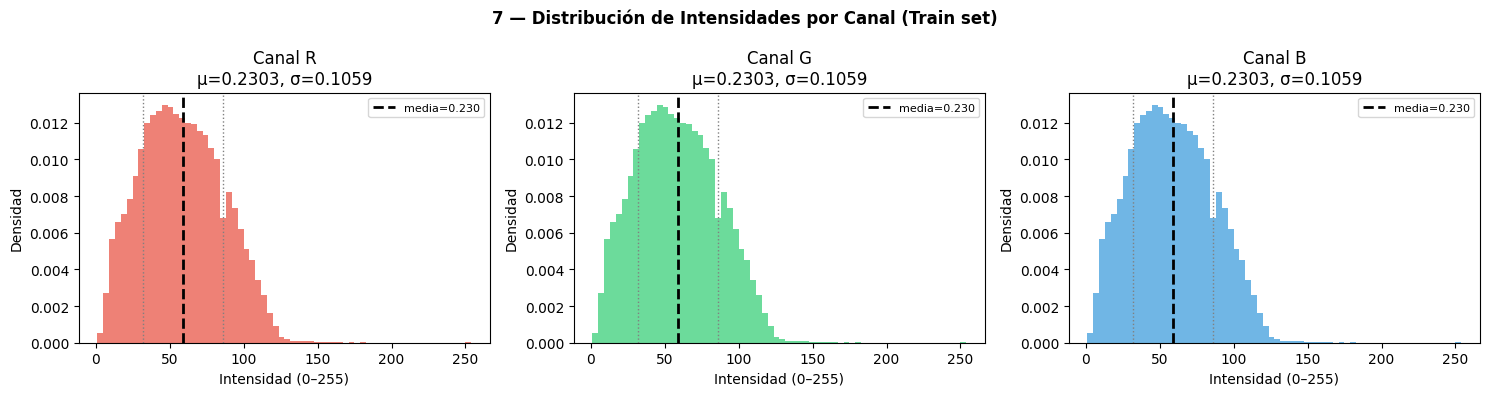


Nota: Como las imágenes MSL son en escala de grises replicada a 3 canales,
los valores R, G, B son prácticamente idénticos.


In [12]:
# Visualización: histograma de intensidades train (muestra)
print("Calculando histograma de intensidades (muestra de 300 imágenes del train)...")

sample_train = train_df.sample(300, random_state=SEED)
all_pixels_r, all_pixels_g, all_pixels_b = [], [], []

for _, row in tqdm(sample_train.iterrows(), total=300, desc="Histograma"):
    stem = Path(row["image_path"]).stem
    img  = np.array(Image.open(IMAGES_256 / f"{stem}.jpg").convert("RGB"))
    flat = img.reshape(-1, 3)
    # Muestrear 500 píxeles por imagen para eficiencia
    idx = np.random.choice(len(flat), size=500, replace=False)
    all_pixels_r.extend(flat[idx, 0].tolist())
    all_pixels_g.extend(flat[idx, 1].tolist())
    all_pixels_b.extend(flat[idx, 2].tolist())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("7 — Distribución de Intensidades por Canal (Train set)",
             fontsize=12, fontweight="bold")

channel_data   = [all_pixels_r, all_pixels_g, all_pixels_b]
channel_names  = ["Canal R", "Canal G", "Canal B"]
channel_colors = ["#E74C3C", "#2ECC71", "#3498DB"]

for ax, data, name, color, mean_val, std_val in zip(
    axes, channel_data, channel_names, channel_colors,
    norm_stats["mean"], norm_stats["std"]
):
    ax.hist(data, bins=64, color=color, alpha=0.7, density=True, edgecolor="none")
    ax.axvline(mean_val * 255, color="black", linewidth=2, linestyle="--",
               label=f"media={mean_val:.3f}")
    ax.axvline((mean_val - std_val) * 255, color="gray", linewidth=1, linestyle=":")
    ax.axvline((mean_val + std_val) * 255, color="gray", linewidth=1, linestyle=":")
    ax.set_xlabel("Intensidad (0–255)")
    ax.set_ylabel("Densidad")
    ax.set_title(f"{name}\nμ={mean_val:.4f}, σ={std_val:.4f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nNota: Como las imágenes MSL son en escala de grises replicada a 3 canales,")
print("los valores R, G, B son prácticamente idénticos.")

## 8. Pesos de clase (solo train) <a id="pesos"></a>

Se calculan pesos inversamente proporcionales a la frecuencia de cada clase
para la función de pérdida con ponderación de clases.

**Fórmula**: `weight_c = total_pixels / (n_classes × count_c)`

Se usan solo los píxeles del **train set** (se excluyen los `ignore=255`).

In [13]:
CLASS_WEIGHTS_FILE = PROCESSED_DIR / "class_weights.json"

if CLASS_WEIGHTS_FILE.exists():
    print("Cargando pesos de clase desde caché...")
    with open(CLASS_WEIGHTS_FILE) as f:
        class_weights_data = json.load(f)
    print(f"  Pesos: {class_weights_data['weights']}")
else:
    print(f"Calculando distribución de píxeles sobre {len(train_df):,} máscaras del train set...")

    pixel_counts = np.zeros(4, dtype=np.int64)

    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Contando píxeles"):
        stem      = Path(row["image_path"]).stem
        mask_path = MASKS_256 / f"{stem}.png"
        mask      = np.array(Image.open(mask_path))
        for c in range(4):
            pixel_counts[c] += int(np.sum(mask == c))

    total_valid = pixel_counts.sum()
    class_freq  = pixel_counts / total_valid

    # Pesos inversamente proporcionales (escalados para que la media sea 1)
    raw_weights = 1.0 / (NUM_CLASSES * class_freq + 1e-8)
    raw_weights = raw_weights / raw_weights.mean()   # escalar

    class_weights_data = {
        "pixel_counts": pixel_counts.tolist(),
        "class_freq":   class_freq.tolist(),
        "weights":      raw_weights.tolist(),
        "class_names":  [CLASS_NAMES[c] for c in range(4)],
        "formula":      "1 / (n_classes * freq), scaled so mean=1",
        "computed_on":  "train set only",
    }
    with open(CLASS_WEIGHTS_FILE, "w") as f:
        json.dump(class_weights_data, f, indent=2)
    print(f"\n✓ class_weights.json guardado")

Calculando distribución de píxeles sobre 4,200 máscaras del train set...


Contando píxeles: 100%|██████████| 4200/4200 [00:02<00:00, 1666.60it/s]


✓ class_weights.json guardado


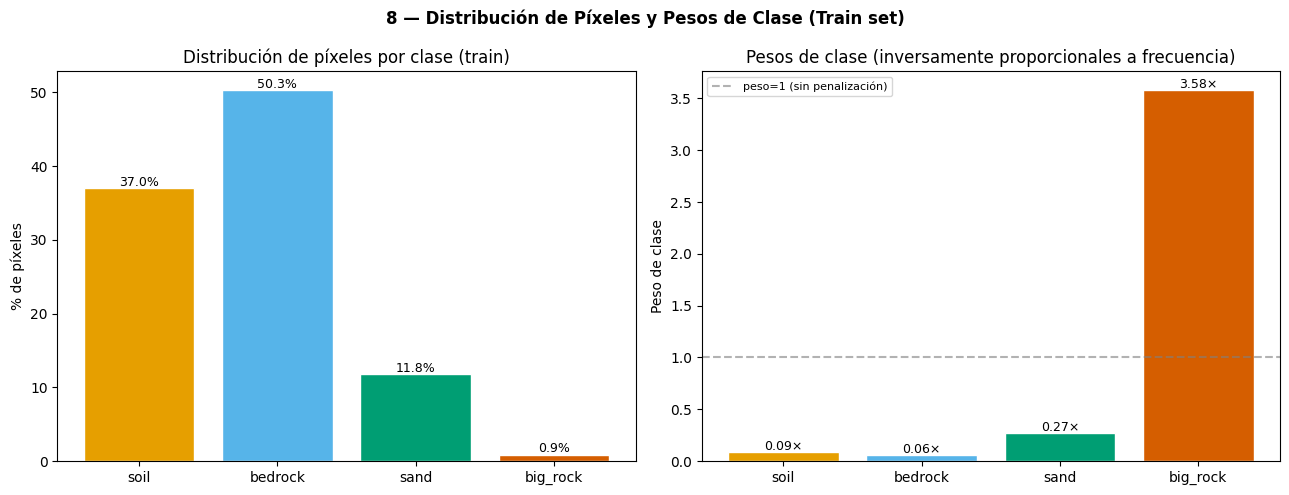

Resumen de clases:
Clase             Píxeles   Frecuencia     Peso
soil           57,913,589       0.3698   0.0860
bedrock        78,805,805       0.5032   0.0632
sand           18,501,632       0.1181   0.2692
big_rock        1,390,419       0.0089   3.5817

big_rock es la clase más rara: 0.89% de los píxeles


In [14]:
# Visualización de distribución de píxeles y pesos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("8 — Distribución de Píxeles y Pesos de Clase (Train set)",
             fontsize=12, fontweight="bold")

cls_labels = [CLASS_NAMES[c] for c in range(4)]
colors_cls = [CLASS_COLORS[c] for c in range(4)]

freqs   = class_weights_data["class_freq"]
weights = class_weights_data["weights"]

# Frecuencia de píxeles
bars = axes[0].bar(cls_labels, [f * 100 for f in freqs], color=colors_cls, edgecolor="white")
for bar, val in zip(bars, freqs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val*100:.1f}%", ha="center", fontsize=9)
axes[0].set_ylabel("% de píxeles")
axes[0].set_title("Distribución de píxeles por clase (train)")

# Pesos de clase
bars2 = axes[1].bar(cls_labels, weights, color=colors_cls, edgecolor="white")
for bar, val in zip(bars2, weights):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.2f}×", ha="center", fontsize=9)
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.6, label="peso=1 (sin penalización)")
axes[1].set_ylabel("Peso de clase")
axes[1].set_title("Pesos de clase (inversamente proporcionales a frecuencia)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Resumen de clases:")
print(f"{'Clase':12s} {'Píxeles':>12s} {'Frecuencia':>12s} {'Peso':>8s}")
for c in range(4):
    print(f"{CLASS_NAMES[c]:12s} "
          f"{class_weights_data['pixel_counts'][c]:>12,} "
          f"{class_weights_data['class_freq'][c]:>12.4f} "
          f"{class_weights_data['weights'][c]:>8.4f}")
print(f"\nbig_rock es la clase más rara: "
      f"{class_weights_data['class_freq'][3]*100:.2f}% de los píxeles")

## 9. Verificación final: no data leakage <a id="leakage"></a>

Verificaciones finales de que la partición es limpia:
1. Train, val y gold test no comparten ningún ID.
2. Los archivos de salida corresponden exactamente al split.
3. Las estadísticas de normalización se calcularon solo sobre train.

In [15]:
gold_ids  = set(df_gold["id"].tolist())
train_ids_set = set(train_df["id"].tolist())
val_ids_set   = set(val_df["id"].tolist())

print("Verificaciones de data leakage:")
print("=" * 50)

# 1. Train ∩ Val
tv_overlap = train_ids_set & val_ids_set
status = "✓" if len(tv_overlap) == 0 else f"✗ LEAKAGE: {len(tv_overlap)} IDs"
print(f"  Train ∩ Val         : {len(tv_overlap)} IDs  [{status}]")

# 2. Train ∩ Gold
tg_overlap = train_ids_set & gold_ids
status = "✓" if len(tg_overlap) == 0 else f"✗ LEAKAGE: {len(tg_overlap)} IDs"
print(f"  Train ∩ Gold test   : {len(tg_overlap)} IDs  [{status}]")

# 3. Val ∩ Gold
vg_overlap = val_ids_set & gold_ids
status = "✓" if len(vg_overlap) == 0 else f"✗ LEAKAGE: {len(vg_overlap)} IDs"
print(f"  Val   ∩ Gold test   : {len(vg_overlap)} IDs  [{status}]")

# 4. Archivos de estadísticas existen
for fname, path in [
    ("split_indices_msl6k.pkl",  SPLIT_FILE),
    ("normalization_stats.json", NORM_STATS_FILE),
    ("class_weights.json",       CLASS_WEIGHTS_FILE),
]:
    status = "✓" if path.exists() else "✗ NO ENCONTRADO"
    print(f"  {fname:35s} [{status}]")

# 5. Dimensiones del split
expected_train = round(N_SUBSET * (1 - VAL_RATIO))
expected_val   = round(N_SUBSET * VAL_RATIO)
print(f"\n  Tamaño train    : {len(train_df):,} (esperado ≈ {expected_train:,})")
print(f"  Tamaño val      : {len(val_df):,} (esperado ≈ {expected_val:,})")
print(f"  Tamaño gold test: {len(df_gold):,} (esperado = 322)")

# Asserts
assert len(tv_overlap) == 0, "DATA LEAKAGE: train y val comparten IDs"
assert len(tg_overlap) == 0, "DATA LEAKAGE: train y gold test comparten IDs"
assert len(vg_overlap) == 0, "DATA LEAKAGE: val y gold test comparten IDs"

print("\n✓ Todas las verificaciones de leakage pasaron.")

Verificaciones de data leakage:
  Train ∩ Val         : 0 IDs  [✓]
  Train ∩ Gold test   : 0 IDs  [✓]
  Val   ∩ Gold test   : 0 IDs  [✓]
  split_indices_msl6k.pkl             [✓]
  normalization_stats.json            [✓]
  class_weights.json                  [✓]

  Tamaño train    : 4,200 (esperado ≈ 4,200)
  Tamaño val      : 1,800 (esperado ≈ 1,800)
  Tamaño gold test: 322 (esperado = 322)

✓ Todas las verificaciones de leakage pasaron.


## 10. Resumen de artefactos generados <a id="resumen"></a>

In [16]:
print("=" * 65)
print("  RESUMEN — Artefactos generados por 02_preprocessing.ipynb")
print("=" * 65)

artefactos = [
    ("data/images_256/",                     f"{len(list(IMAGES_256.glob('*.jpg'))):,} archivos .jpg (256×256)"),
    ("data/masks_256/",                      f"{len(list(MASKS_256.glob('*.png'))):,} archivos .png (256×256)"),
    ("notebooks/processed/split_indices_msl6k.pkl",
     f"Train={len(train_df):,} | Val={len(val_df):,} | seed={SEED}"),
    ("notebooks/processed/normalization_stats.json",
     f"mean={[f'{v:.4f}' for v in norm_stats['mean']]} | std={[f'{v:.4f}' for v in norm_stats['std']]}"),
    ("notebooks/processed/class_weights.json",
     f"weights={[f'{v:.4f}' for v in class_weights_data['weights']]}"),
    ("notebooks/processed/manifest_msl_dominant.csv",
     f"{len(df_msl_train):,} entradas con clase dominante"),
]

for path, desc in artefactos:
    print(f"\n  📁 {path}")
    print(f"     {desc}")

print("\n" + "=" * 65)
print("  PRÓXIMO PASO")
print("=" * 65)
print("""
  03_eda_msl.ipynb — EDA profundo sobre el subconjunto MSL procesado:
    - Distribución de intensidades por clase (sobre train set)
    - Análisis de bordes y complejidad de frontera
    - Baselines triviales (predictor mayoritario, por frecuencia)
    - Visualización de muestras difíciles (big_rock en contexto)

  ⚠️  Recordar subir split_indices_msl6k.pkl al repositorio antes
      de que los compañeros ejecuten sus notebooks de modelos.
""")

  RESUMEN — Artefactos generados por 02_preprocessing.ipynb

  📁 data/images_256/
     6,322 archivos .jpg (256×256)

  📁 data/masks_256/
     6,322 archivos .png (256×256)

  📁 notebooks/processed/split_indices_msl6k.pkl
     Train=4,200 | Val=1,800 | seed=42

  📁 notebooks/processed/normalization_stats.json
     mean=['0.2303', '0.2303', '0.2303'] | std=['0.1059', '0.1059', '0.1059']

  📁 notebooks/processed/class_weights.json
     weights=['0.0860', '0.0632', '0.2692', '3.5817']

  📁 notebooks/processed/manifest_msl_dominant.csv
     15,901 entradas con clase dominante

  PRÓXIMO PASO

  03_eda_msl.ipynb — EDA profundo sobre el subconjunto MSL procesado:
    - Distribución de intensidades por clase (sobre train set)
    - Análisis de bordes y complejidad de frontera
    - Baselines triviales (predictor mayoritario, por frecuencia)
    - Visualización de muestras difíciles (big_rock en contexto)

  ⚠️  Recordar subir split_indices_msl6k.pkl al repositorio antes
      de que los compa